## 1. Introduction

This project analyzes agricultural activities across different seasons using environmental, farming, resource, production and economic variables. The purpose is to compare seasonal performance and identify data-driven insights, patterns, trends and variations.

## Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

## Objective
The primary objective of this project is to analyze agricultural data from different seasons
and identify meaningful patterns, trends, relationships and differences in agricultural
performance.
Students should independently:
-Explore and understand the dataset.  
- Clean and prepare the data for analysis.  
- Examine how agricultural performance varies across seasons.  
- Identify important seasonal patterns and trends.  
- Investigate relationships between seasonal conditions and agricultural outcomes.  
- Compare relevant groups within different seasons.  
- Identify significant differences or unusual patterns.  
- Apply appropriate statistical and visualization techniques.  
- Interpret findings based on evidence from the dataset.  
- Develop meaningful conclusions and data-driven recommendations.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('plots', exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [15]:
import pandas as pd

df = pd.read_csv('/content/Seasonal_Agriculture_Performance_Analysis/seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (4000, 28)


## 1. Top 5 rows analyzed

In [16]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 2. Dataset shape and structure

In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nDataset structure:")
df.info()

Rows: 4000
Columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                 

## 3. Data types examined

In [18]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


## 4. Handling Missing values

In [19]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values before handling:")
print(missing)

numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print("\nMissing values after handling:")
print(df.isnull().sum().sum())


Missing values before handling:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Missing values after handling:
0


## 5.Identified and handled duplicate records

In [21]:
duplicates = df.duplicated().sum()
print("Duplicate records:", duplicates)

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate handling:", df.shape)

Duplicate records: 0
Shape after duplicate handling: (4000, 28)


## 6. Descriptive/statistical analysis

In [22]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",NaN,NaN,NaN,600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


## 7. Outliers investigated

In [23]:
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Variable','Q1','Q3','Lower_Bound','Upper_Bound','Outlier_Count']
).sort_values('Outlier_Count', ascending=False)

outlier_df

,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
18,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404
14,Production_Tonnes,5.02,24.36,-23.98,53.36,333
20,Water_Efficiency_t_per_1000m3,1.66,5.15,-3.57,10.38,322
13,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302
19,Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276
17,Revenue_INR,"207,517.25","836,874.75","-736,519.00","1,780,911.00",240
9,Potassium_kg_ha,86.20,123.60,30.10,179.70,32
4,Sunlight_Hours_Day,6.60,8.10,4.35,10.35,26
8,Phosphorus_kg_ha,46.20,69.40,11.40,104.20,16
10,Fertilizer_kg_ha,143.97,227.20,19.14,352.04,15


## 8. Univariate analysis

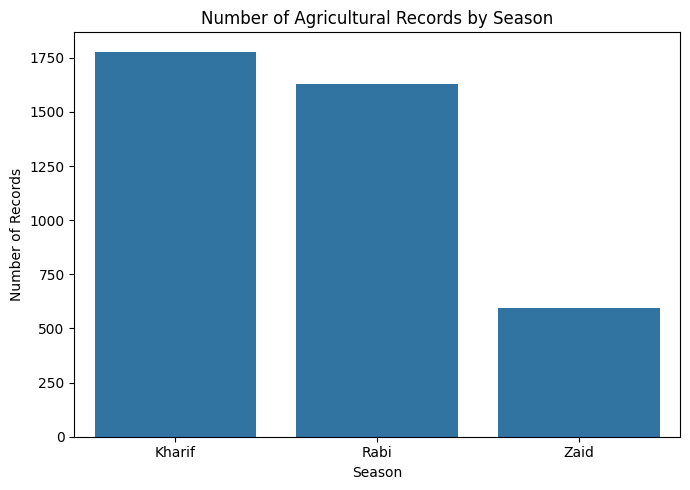

In [30]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index)
plt.title('Number of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.savefig('plots/01_season_distribution.png', dpi=200)
plt.show()


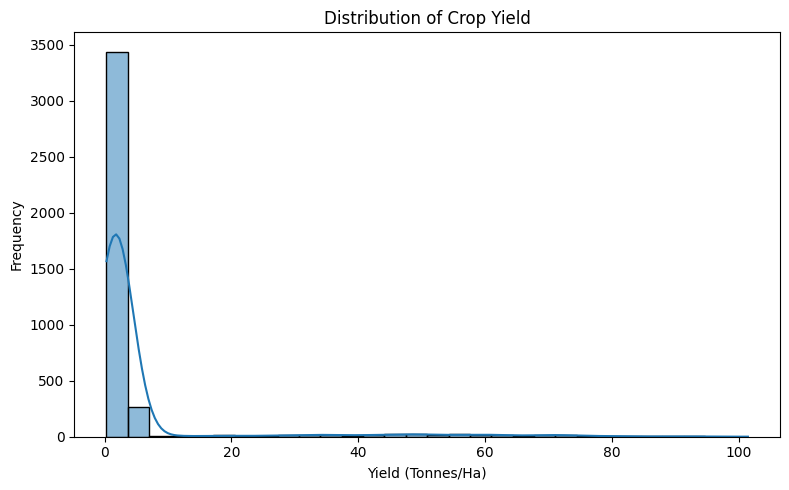

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['Yield_Tonnes_Ha'], bins=30, kde=True)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/02_yield_distribution.png', dpi=200)
plt.show()

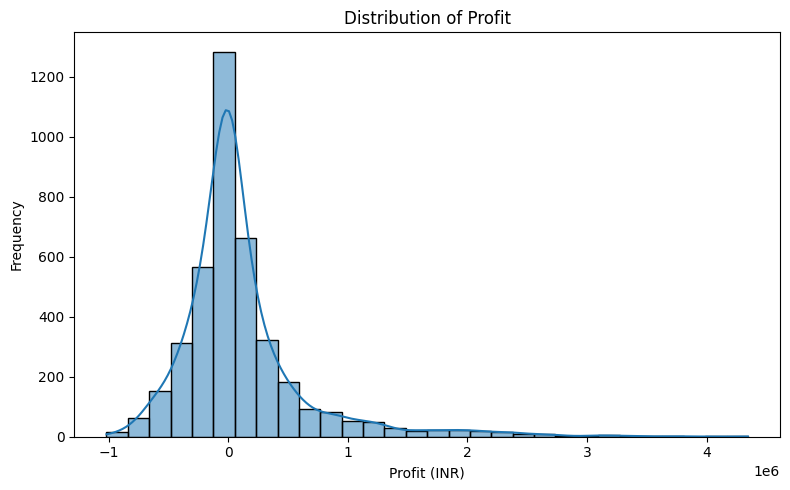

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df['Profit_INR'], bins=30, kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/03_profit_distribution.png', dpi=200)
plt.show()

## 9. Bivariate analysis

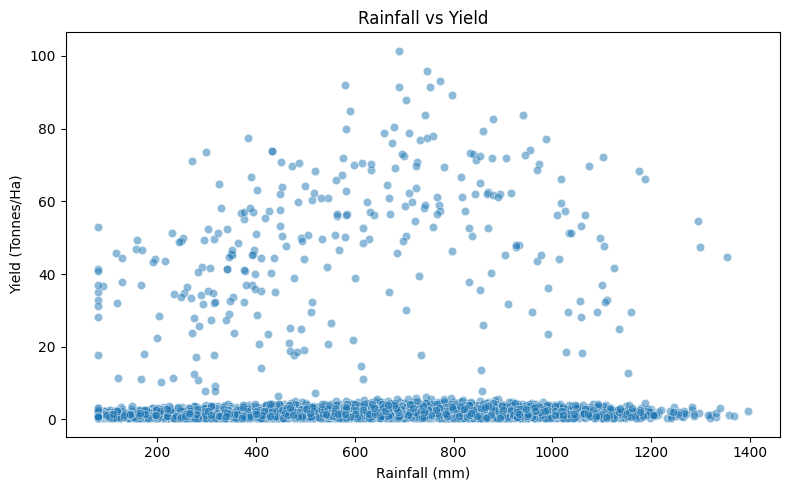

In [33]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.5)
plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.savefig('plots/04_rainfall_vs_yield.png', dpi=200)
plt.show()

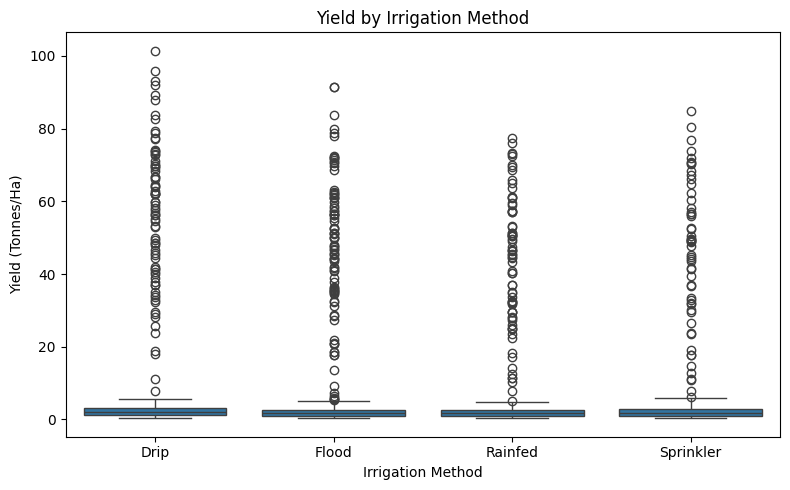

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha')
plt.title('Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.savefig('plots/05_yield_by_irrigation.png', dpi=200)
plt.show()

## 10. Multivariate analysis

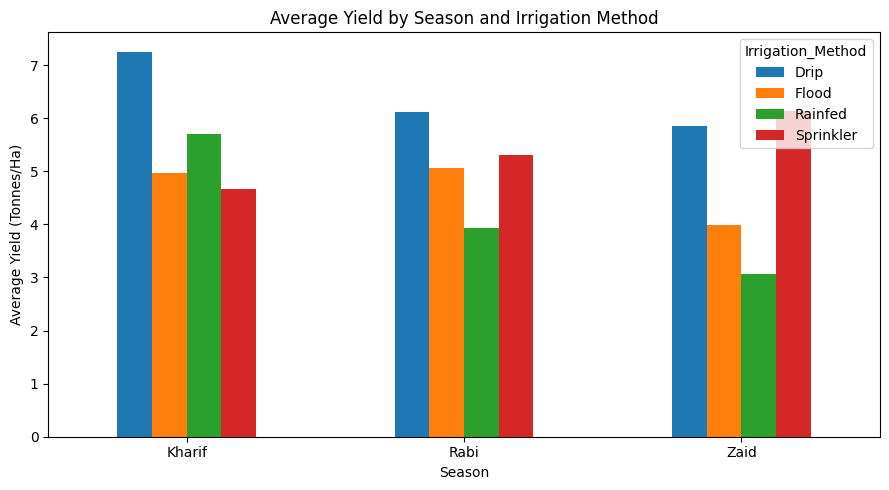

In [36]:
avg_yield = df.groupby(
    ['Season', 'Irrigation_Method']
)['Yield_Tonnes_Ha'].mean().unstack()

avg_yield.plot(kind='bar', figsize=(9, 5))

plt.title('Average Yield by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('plots/06_season_irrigation_yield.png', dpi=200)

plt.show()

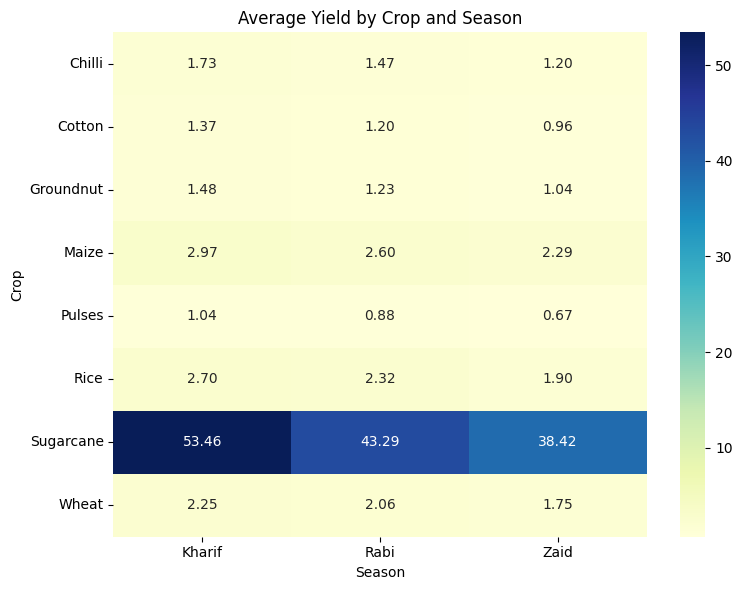

In [37]:
crop_season = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)
plt.figure(figsize=(8, 6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.savefig('plots/07_crop_season_heatmap.png', dpi=200)

plt.show()

## 11. Correlation analysis

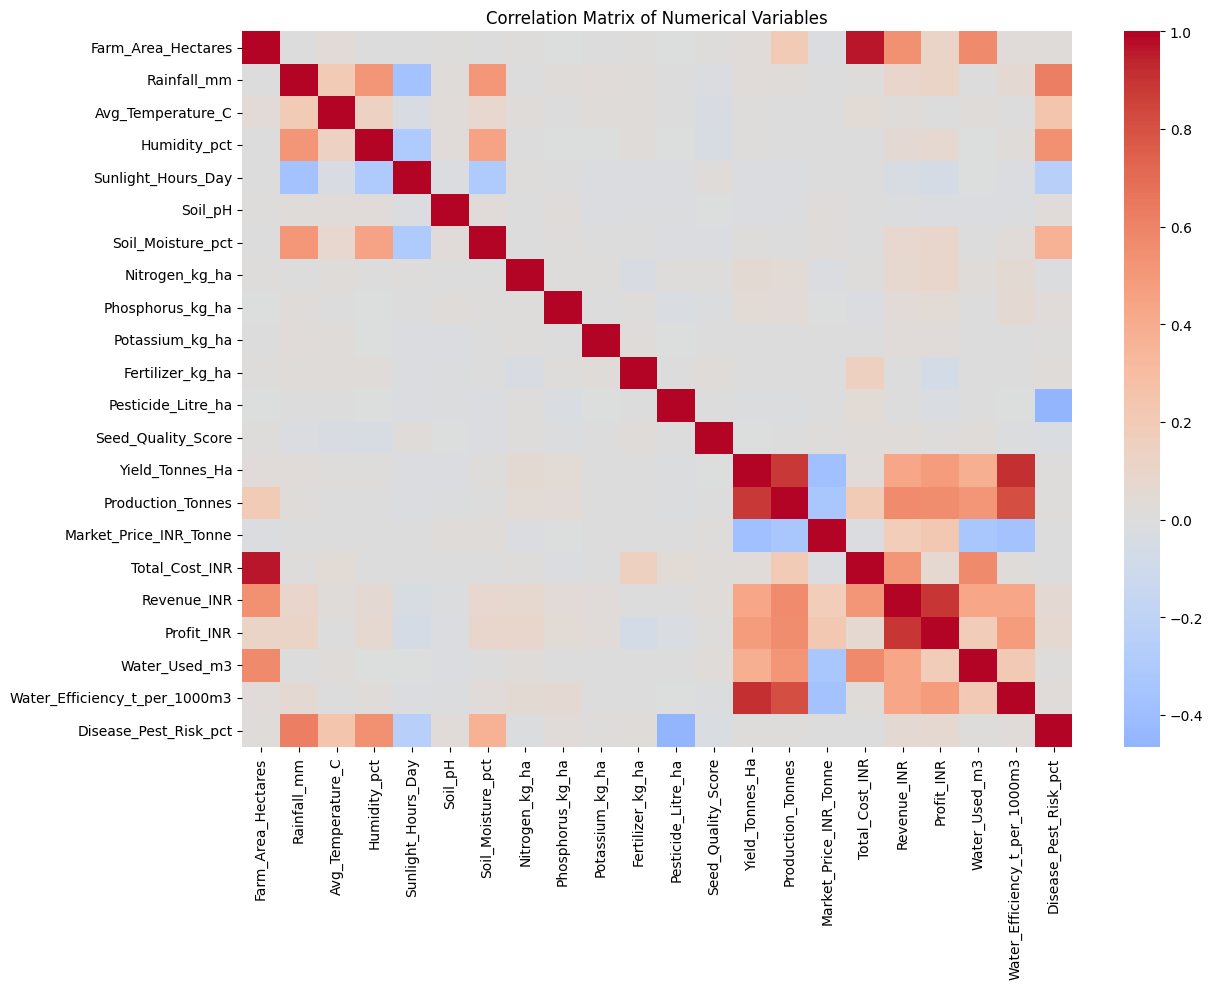

Correlation with Yield:
Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Farm_Area_Hectares               0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64


In [38]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(13,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.savefig('plots/08_correlation_matrix.png', dpi=200)
plt.show()

print("Correlation with Yield:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False))

## 12. Seasonal comparisons

In [39]:
season_summary = df.groupby('Season').agg(
    Records=('Farm_ID', 'count'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Yield_Tonnes_Ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production_Tonnes=('Production_Tonnes', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2)

season_summary

,Records,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,,,,,,
Kharif,1779,849.20,28.45,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,1627,437.62,23.49,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,594,304.65,31.04,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22


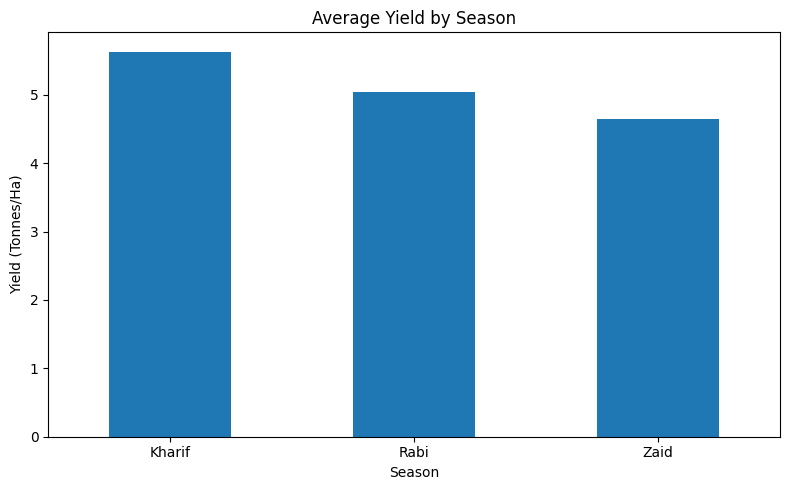

In [40]:
fig, ax = plt.subplots(figsize=(8,5))
season_summary['Avg_Yield_Tonnes_Ha'].plot(kind='bar', ax=ax)
ax.set_title('Average Yield by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Yield (Tonnes/Ha)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('plots/09_seasonal_yield_comparison.png', dpi=200)
plt.show()

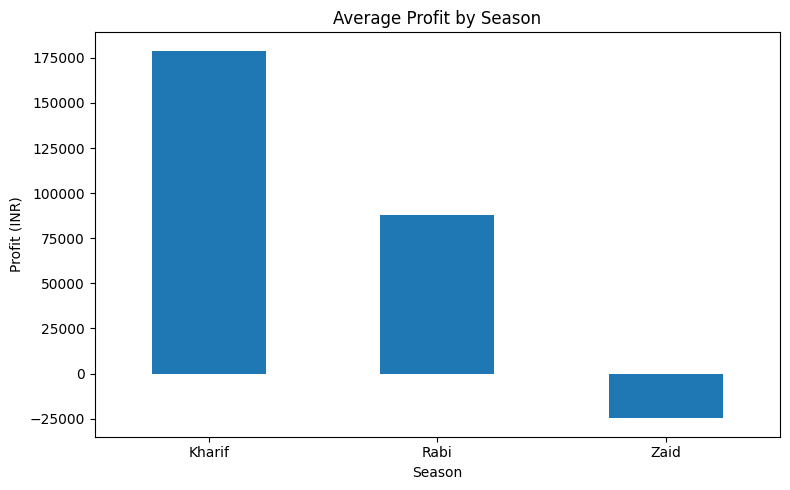

In [41]:
fig, ax = plt.subplots(figsize=(8,5))
season_summary['Avg_Profit_INR'].plot(kind='bar', ax=ax)
ax.set_title('Average Profit by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Profit (INR)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('plots/10_seasonal_profit_comparison.png', dpi=200)
plt.show()

## 13. Student-designed analysis

Analysis 1 — Best irrigation method within each season

In [42]:
analysis1 = df.groupby(
    ['Season','Irrigation_Method']
)['Yield_Tonnes_Ha'].mean().reset_index()

best_irrigation = analysis1.loc[
    analysis1.groupby('Season')['Yield_Tonnes_Ha'].idxmax()
].sort_values('Season')

print(best_irrigation)

    Season Irrigation_Method  Yield_Tonnes_Ha
0   Kharif              Drip             7.26
4     Rabi              Drip             6.11
11    Zaid         Sprinkler             6.14


Analysis 2 — Crop performance across seasons

Season     Kharif  Rabi  Zaid
Crop                         
Chilli       1.73  1.47  1.20
Cotton       1.37  1.20  0.96
Groundnut    1.48  1.23  1.04
Maize        2.97  2.60  2.29
Pulses       1.04  0.88  0.67
Rice         2.70  2.32  1.90
Sugarcane   53.46 43.29 38.42
Wheat        2.25  2.06  1.75


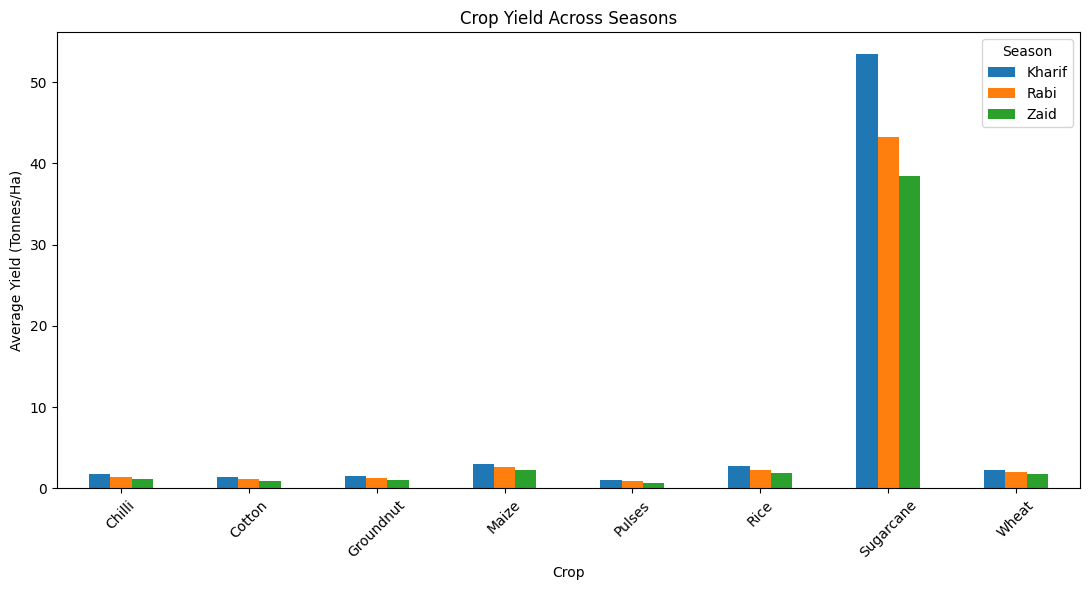

In [43]:
crop_season_summary = df.groupby(
    ['Crop','Season']
)['Yield_Tonnes_Ha'].mean().unstack()

print(crop_season_summary.round(2))

crop_season_summary.plot(kind='bar', figsize=(11,6))
plt.title('Crop Yield Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/11_crop_yield_across_seasons.png', dpi=200)
plt.show()

Analysis 3 — State-wise agricultural performance

In [44]:
state_summary = df.groupby('State').agg(
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).sort_values('Avg_Profit', ascending=False)

state_summary.round(2)

,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,,,
Punjab,6.12,"136,025.64",5.62
Maharashtra,5.02,"135,428.86",5.28
Karnataka,5.69,"119,422.34",5.56
Tamil Nadu,4.88,"117,744.75",5.31
Gujarat,5.66,"117,568.24",5.58
Telangana,5.04,"108,829.62",5.46
Madhya Pradesh,4.99,"86,840.76",5.27
Andhra Pradesh,4.63,"73,453.53",5.03


Evidence-based insights

INSIGHTS

1. Kharif has the highest average yield compared to Rabi and Zaid.

2. Kharif has the highest average profit, whereas Zaid shows a negative average profit.

3. Kharif receives much more rainfall compared to Rabi and Zaid.

4. Water efficiency is highest during Kharif and lowest during Zaid.

5. Drip irrigation gives the best average yield during Kharif and Rabi.

6. In Zaid, sprinkler irrigation gives the highest average yield.

7. Sugarcane has a much higher yield per hectare than the other crops, so crop type should be considered while comparing yields.

8. Punjab has the highest average yield and profit among the states included in the dataset.

9. Yield has a strong positive relationship with water efficiency and production, while market price has a negative relationship with yield.

10. Crop performance changes across seasons, so the same farming strategy may not work equally well for every crop.

## 17. Evidence-based recommendations

1. Prioritize crop and irrigation strategies by season instead of using one common approach.
2. Consider efficient irrigation methods such as drip where appropriate, especially in Kharif and Rabi.
3. In Zaid, investigate sprinkler irrigation because it produced the highest average yield among the listed irrigation methods.
4. Review the economic feasibility of Zaid cultivation because its average profit is negative in this dataset.
5. Use crop-specific seasonal planning because crop yields change differently across seasons.
6. Monitor water efficiency together with yield rather than maximizing yield alone.
7. Use state-level performance differences to identify regions needing further investigation and knowledge transfer.



## 18. Limitations



- The analysis is based only on the variables available in the supplied dataset.
- Missing numeric values were imputed using medians, which may reduce natural variation.
- Observed relationships and correlations do not by themselves prove causation.
- Some variables are mathematically related (for example, production depends on yield and farm area), so their correlations should be interpreted carefully.
- The dataset may not represent every agricultural region, crop, farm size, or market condition in India.



## 19. Final conclusion

The analysis shows that agricultural performance varies across different seasons. Kharif has the highest average yield, revenue, profit, and water efficiency in this dataset, while Zaid shows comparatively weaker economic performance. The effectiveness of irrigation also changes from season to season, and different crops perform differently under different seasonal conditions. Overall, the results suggest that better agricultural planning should consider crop type, irrigation method, water usage, environmental conditions, and economic factors together. These findings can help in making better seasonal farming decisions, although the results are based only on the available dataset.
